# Deep Learning for American Put Option Pricing
## Theoretical Foundations and Numerical Motivation

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `01_option_pricing_foundations.ipynb`

This notebook establishes the theoretical and empirical motivation for the project. It combines academic discussion with small executable demonstrations. Production pricing logic remains in `src/`, while the notebook imports those functions, visualizes their behaviour, and interprets the results.

> This project is an academic exercise. It does not constitute investment advice, a trading recommendation, or a production-ready valuation framework.

## Provisional abstract

American options differ from European options because the holder may exercise before contractual maturity. This flexibility creates an optimal-stopping problem: at each admissible exercise date, the holder compares immediate exercise with the expected discounted continuation value. Except in limited special cases, this removes the closed-form solution and requires numerical valuation.

This project investigates whether deep neural networks can approximate American put values and early-exercise decisions with sufficient accuracy, financial consistency, and computational efficiency to serve as surrogate models for repeated numerical valuation. Synthetic labels will be generated by a high-resolution Cox–Ross–Rubinstein tree and independently validated against QuantLib. A direct multilayer perceptron will be compared with a financially structured model that predicts only the early-exercise premium over the corresponding European Black–Scholes value. A multi-task extension will jointly estimate price and the exercise-versus-continuation decision.

Evaluation will include segmented pricing errors, financial lower-bound and monotonicity violations, exercise-boundary accuracy, out-of-domain deterioration, and inference speed. The objective is not to claim that deep learning discovers a superior theoretical price, but to test whether it can provide a fast and financially coherent approximation of a clearly specified numerical pricing model.

> The abstract will be rewritten after the empirical results are available.

**Keywords:** American put option; deep learning; early-exercise premium; optimal stopping; binomial tree; Black–Scholes; Least-Squares Monte Carlo; surrogate pricing

# 1. Environment and project structure

The notebook is expected to live under `notebooks/`, while reusable code will live under `src/`. The setup cell adds the project root to the Python path. The first numerical demonstrations run independently; later cells require `src/pricing/black_scholes.py` and `src/pricing/binomial_tree.py`.

In [1]:
#Import your libraries here

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Notebook directory: {NOTEBOOK_DIR}")
print(f"Project root:       {PROJECT_ROOT}")

Notebook directory: /storage/deep_learning_american_option_pricing/notebooks
Project root:       /storage/deep_learning_american_option_pricing


In [2]:
#Import your modules here

from src.pricing.black_scholes import (
    black_scholes_call_price,
    black_scholes_put_price,
)

from src.pricing.binomial_tree import crr_option_price


# 2. Motivation and continuity with previous work

This project continues my earlier SoftUni *Math for Developers* final project, [Mathematical Foundations of Portfolio Optimization and Hedging](https://github.com/Kamend1/math_for_developers_final_project). That work connected portfolio optimization, Black–Scholes pricing, protective puts, Greeks, convexity, and embedded optionality.

The earlier project concentrated on European-style valuation, where Black–Scholes provides a closed-form solution under restrictive assumptions. The present project moves to a harder problem: an American option may be exercised before maturity, so valuation includes a decision problem.

While in the Data Science and Machine Learning courses' final projects I looked attempting work of my own design, developing certain ideas that I had long sought to exploit, in this course I could not really find a novel topic, which has not been throurughly researched for the application of deep learning methods. I have selected several of the most interesting articles I have come across in my own research and I will attempt to reproduce variable approaches and comment on the findings from my own perspective. I hope that I will be able to provide viable business applications, test valid hypothesis and provide scientifically sound answers without fallacies in the research.

Training a neural network merely to reproduce Black–Scholes pricing model would demonstrate function approximation but create limited practical value because the analytical formula already exists and is computationally cheap. Elbayed and Qadi El Idrissi (2025) provide a useful baseline by showing that a dense network can approximate synthetic European put prices very successfuly. 

I see the stronger application lying in the work to approximate a numerical pricing procedure that becomes expensive when repeated across large portfolios, scenario grids, or risk calculations and there building deep learning models can have a visible advantage. I will use ideas of the models described in the papers I have researched, explore the results and comment on the findings as they come out. 

# 3. Representative contract

A slightly in-the-money American put is useful for the first demonstration because immediate exercise may become economically relevant. The values below are controlled model parameters, not market observations.

In [3]:
example_option = {
    "spot": 90.0,
    "strike": 100.0,
    "time_to_maturity": 1.0,
    "risk_free_rate": 0.05,
    "dividend_yield": 0.02,
    "volatility": 0.25,
}

pd.Series(example_option, name="Value").to_frame()

,Value
spot,90.00
strike,100.00
time_to_maturity,1.00
risk_free_rate,0.05
dividend_yield,0.02
volatility,0.25


# 4. Intrinsic value and immediate exercise

For a put option,

$$
I(S)=\max(K-S,0).
$$

This is the value available from immediate exercise and therefore a lower bound for an American put:

$$
V_A\geq\max(K-S,0).
$$

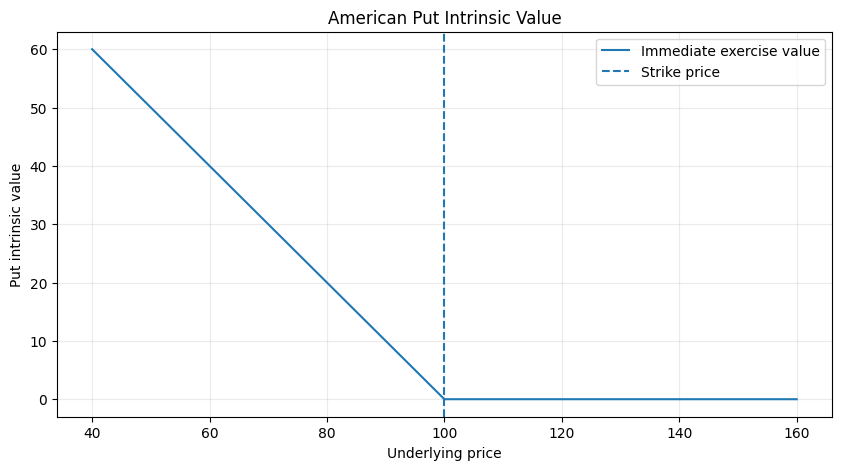

In [4]:
spot_grid = np.linspace(40.0, 160.0, 500)
strike = example_option["strike"]
put_intrinsic = np.maximum(strike - spot_grid, 0.0)

plt.figure(figsize=(10, 5))
plt.plot(spot_grid, put_intrinsic, label="Immediate exercise value")
plt.axvline(strike, linestyle="--", label="Strike price")
plt.xlabel("Underlying price")
plt.ylabel("Put intrinsic value")
plt.title("American Put Intrinsic Value")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

The payoff is linear below the strike and zero above it. It is not the complete option value because it ignores the value of waiting and retaining exposure to future uncertainty.

# 5. European Black–Scholes benchmark

With continuous dividend yield,

$$
P_E=Ke^{-rT}N(-d_2)-Se^{-qT}N(-d_1),
$$

where

$$
d_1=\frac{\ln(S/K)+(r-q+\frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}},
\qquad d_2=d_1-\sigma\sqrt{T}.
$$

The European value is a benchmark, a lower bound for the corresponding American option, and the known component of the proposed early-exercise-premium model.

In [5]:
european_put = black_scholes_put_price(**example_option)
intrinsic_value = max(example_option["strike"] - example_option["spot"], 0.0)

print(f"European Black–Scholes put: {european_put:.6f}")
print(f"Immediate exercise value:  {intrinsic_value:.6f}")

European Black–Scholes put: 12.980402
Immediate exercise value:  10.000000


# 6. American valuation as optimal stopping

At each node, the holder compares intrinsic value with continuation value:

$$
V_A(S_t,t)=\max\left(I(S_t),C(S_t,t)\right).
$$

The Cox–Ross–Rubinstein (CRR) tree implements this comparison recursively by backward induction (Cox, Ross, and Rubinstein, 1979).

In [6]:
american_put = crr_option_price(
    **example_option,
    steps=1_000,
    option_type="put",
    exercise_style="american",
)

european_tree_put = crr_option_price(
    **example_option,
    steps=1_000,
    option_type="put",
    exercise_style="european",
)

early_exercise_premium = american_put - european_put

pd.DataFrame(
    {
        "Valuation": [
            "Immediate exercise",
            "European Black–Scholes",
            "European CRR tree",
            "American CRR tree",
            "Early-exercise premium",
        ],
        "Value": [
            intrinsic_value,
            european_put,
            european_tree_put,
            american_put,
            early_exercise_premium,
        ],
    }
)

,Valuation,Value
0,Immediate exercise,10.000000
1,European Black–Scholes,12.980402
2,European CRR tree,12.981868
3,American CRR tree,13.660600
4,Early-exercise premium,0.680198


The early-exercise premium is

$$
EEP=V_A-V_E.
$$

Because the American contract includes all exercise rights available under the European contract,

$$
V_A\geq V_E\quad\Rightarrow\quad EEP\geq0.
$$

This motivates the main neural architecture:

$$
\widehat V_A=V_{BS}+\operatorname{Softplus}(g_\theta(x)).
$$

# 7. Price functions across moneyness

The next experiment compares intrinsic, European, and American values across a spot-price grid while keeping the other parameters fixed. The vertical difference between the American and European curves is the early-exercise premium.

In [7]:
def price_across_spot_grid(
    spot_values: np.ndarray,
    *,
    strike: float,
    time_to_maturity: float,
    risk_free_rate: float,
    dividend_yield: float,
    volatility: float,
    steps: int = 500,
) -> pd.DataFrame:
    rows = []

    for spot in spot_values:
        common = {
            "spot": float(spot),
            "strike": strike,
            "time_to_maturity": time_to_maturity,
            "risk_free_rate": risk_free_rate,
            "dividend_yield": dividend_yield,
            "volatility": volatility,
        }

        european = black_scholes_put_price(**common)
        american = crr_option_price(
            **common,
            steps=steps,
            option_type="put",
            exercise_style="american",
        )

        rows.append(
            {
                "spot": float(spot),
                "intrinsic": max(strike - spot, 0.0),
                "european_put": european,
                "american_put": american,
                "early_exercise_premium": american - european,
            }
        )

    return pd.DataFrame(rows)


price_grid = price_across_spot_grid(
    np.linspace(50.0, 150.0, 101),
    strike=example_option["strike"],
    time_to_maturity=example_option["time_to_maturity"],
    risk_free_rate=example_option["risk_free_rate"],
    dividend_yield=example_option["dividend_yield"],
    volatility=example_option["volatility"],
)

price_grid.head()

,spot,intrinsic,european_put,american_put,early_exercise_premium
0,50.0,50.0,46.133980,50.0,3.866020
1,51.0,49.0,45.160092,49.0,3.839908
2,52.0,48.0,44.187737,48.0,3.812263
3,53.0,47.0,43.217195,47.0,3.782805
4,54.0,46.0,42.248779,46.0,3.751221


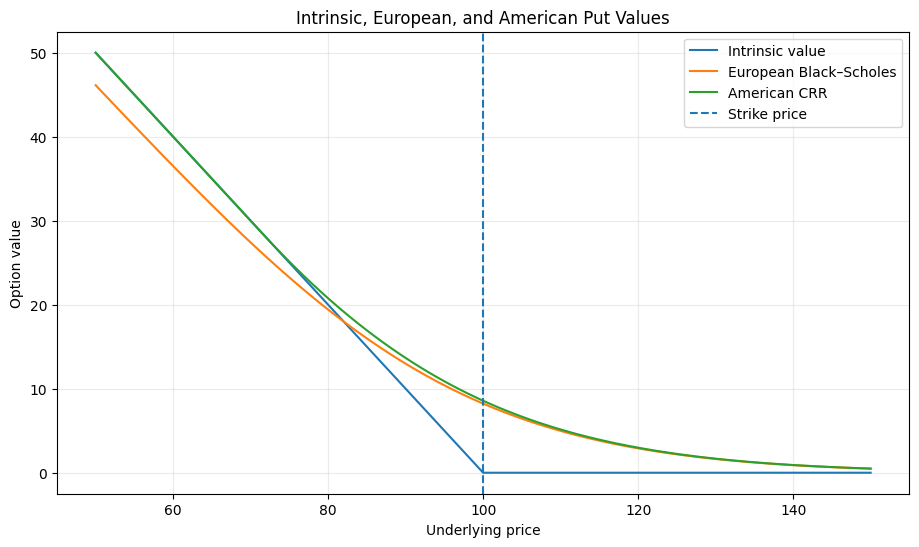

In [8]:
plt.figure(figsize=(11, 6))
plt.plot(price_grid["spot"], price_grid["intrinsic"], label="Intrinsic value")
plt.plot(price_grid["spot"], price_grid["european_put"], label="European Black–Scholes")
plt.plot(price_grid["spot"], price_grid["american_put"], label="American CRR")
plt.axvline(example_option["strike"], linestyle="--", label="Strike price")
plt.xlabel("Underlying price")
plt.ylabel("Option value")
plt.title("Intrinsic, European, and American Put Values")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

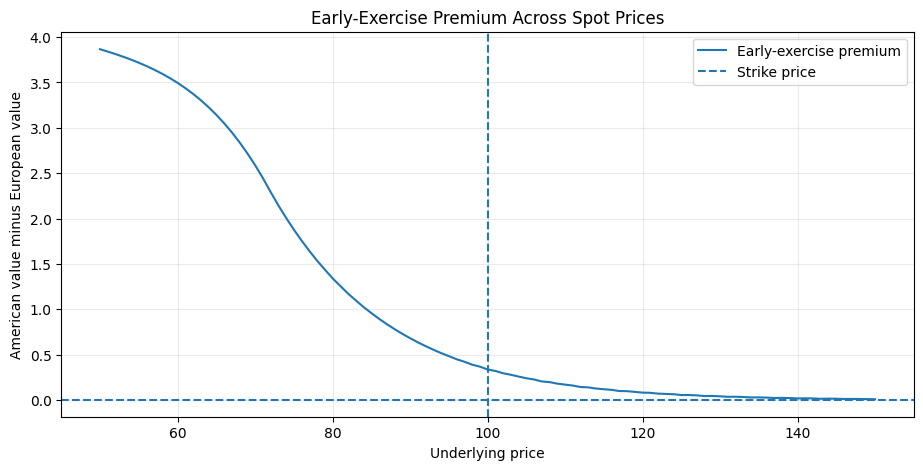

In [9]:
plt.figure(figsize=(11, 5))
plt.plot(price_grid["spot"], price_grid["early_exercise_premium"], label="Early-exercise premium")
plt.axhline(0.0, linestyle="--")
plt.axvline(example_option["strike"], linestyle="--", label="Strike price")
plt.xlabel("Underlying price")
plt.ylabel("American value minus European value")
plt.title("Early-Exercise Premium Across Spot Prices")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

The largest modeling difficulty is expected near the exercise boundary, where the optimal decision changes from continuation to immediate exercise. Aggregate error metrics alone may hide failures in this economically important region.

# 8. Visible financial sanity checks

The formal tests live under `tests/`, but the notebook displays the central checks for the representative calculation.

In [10]:
sanity_checks = pd.Series(
    {
        "American value is non-negative": american_put >= 0.0,
        "American value >= intrinsic value": american_put >= intrinsic_value,
        "American value >= European value": american_put >= european_put,
        "Early-exercise premium is non-negative": early_exercise_premium >= 0.0,
        "European CRR is close to Black–Scholes": np.isclose(
            european_tree_put,
            european_put,
            atol=0.02,
        ),
    },
    name="Passed",
)

sanity_checks.to_frame()

,Passed
American value is non-negative,True
American value >= intrinsic value,True
American value >= European value,True
Early-exercise premium is non-negative,True
European CRR is close to Black–Scholes,True


In [11]:
assert sanity_checks.all(), "At least one financial sanity check failed."

# 9. Literature review and model positioning

## Direct supervised pricing

Ke and Yang (2019) compare a multi-layer perceptron (MLP) and long short-term memory network (LSTM) architectures on historical option data. Their strongest model predicts bid and ask values separately, while their LSTM does not outperform the MLP alternatives. Elbayed and Qadi El Idrissi (2025) demonstrate that a dense network can approximate European put prices generated from Black–Scholes. These studies support a transparent feed-forward baseline but do not resolve the American optimal-stopping problem.

## Sequential models

Pimentel et al. (2026) use five-day SPX European call sequences and a rolling-window design. Their LSTM outperforms Black–Scholes, Heston, and MLP benchmarks at an aggregate level, particularly for longer maturities. Zouaoui and Naas (2023) discuss LSTM and recurrent neural network (GRU) approaches while emphasizing overfitting, data quality, computational cost, and interpretability.

These findings support recurrent architectures when inputs are genuinely sequential. The core synthetic dataset in this project contains static pricing parameters, so an LSTM will not be used merely to increase apparent model sophistication.

## American options and richer state representations

Pu (2021) compares supervised neural pricing with neural partfial differential equation (PDE) methods and documents material out-of-domain deterioration. Ding, Lu, and Cheung (2025) compress implied-volatility surfaces with a variational autoencoder and use the latent variables to price QuantLib-generated American puts and Asian options. Their work provides a credible future extension, but the core project begins with constant volatility to isolate the early-exercise problem.

# 10. Research goals and questions

The contribution is narrower than the broad statement that deep learning can price options:

> Can a financially structured neural network learn the American early-exercise premium and exercise boundary more accurately and consistently than a generic direct-price network, while delivering a measurable inference-speed advantage over a numerical benchmark?

**RQ1.** Can a conventional MLP approximate high-resolution American put prices within a predefined domain?  
**RQ2.** Does predicting the early-exercise premium improve accuracy or training efficiency?  
**RQ3.** Do financial constraints reduce impossible predictions?  
**RQ4.** Can a multi-task network jointly learn price and exercise decision?  
**RQ5.** How do errors vary across parameter regimes?  
**RQ6.** How materially does performance deteriorate outside the training domain?  
**RQ7.** Does neural inference provide a meaningful speed advantage?

# 11. Predefined hypotheses

### H1 — Direct approximation
A direct MLP will outperform the European Black–Scholes proxy for in-domain American put pricing.

### H2 — Premium decomposition
A model trained on the early-exercise premium will outperform a model trained on the complete American value.

### H3 — Financial constraints
A constrained premium model will produce fewer non-negativity and lower-bound violations.

### H4 — Multi-task exercise learning
Joint pricing and exercise classification will improve exercise-boundary accuracy.

### H5 — Computational acceleration
Batched neural inference will be substantially faster than repeated high-resolution tree valuation.

### H6 — Out-of-domain deterioration
All neural models will perform materially worse on excluded parameter regions.

# 12. Scope and methodology

## Core scope

- American put options;
- constant volatility, rates, and continuous dividend yield;
- synthetic labels from a validated numerical engine;
- feed-forward neural networks;
- early-exercise-premium prediction;
- exercise-boundary analysis;
- in-domain and out-of-domain tests.

## Input representation

$$
x=[\log(S/K),T,r,q,\sigma],
\qquad y=V_A/K.
$$

## Models

1. European Black–Scholes proxy;
2. direct MLP;
3. early-exercise-premium MLP;
4. constrained premium MLP;
5. multi-task price and exercise model;
6. neural Least-Squares Monte Carlo extension.

## Evaluation

MAE, RMSE, normalized error, median and maximum absolute error, \(R^2\), exercise F1, financial-constraint violation rates, and inference time. MAPE will not be primary because it is unstable near zero option values.

# 13. Reproducibility and leakage controls

The data will be split into training, validation, in-domain test, and separate out-of-domain test sets. Entire parameter regions will be excluded from training to test extrapolation honestly. All normalization statistics will be fitted on the training set only.

Reusable logic remains in `src/`. Tests verify benchmark values, put–call parity, tree convergence, American lower bounds, non-dividend American call equivalence, invalid inputs, and deterministic behaviour.

A neural network trained on an incorrect pricing engine will learn the error rather than correct it. Numerical validation is therefore a prerequisite for large-scale data generation.

# 14. Anticipated limitations

- Synthetic labels inherit the assumptions and errors of the generating model.
- Constant volatility does not reproduce market volatility smiles.
- Continuous dividends do not capture discrete corporate dividend events.
- A numerical benchmark is still an approximation.
- Random sampling may underrepresent the exercise boundary.
- Strong interpolation does not imply reliable extrapolation.
- Inference-speed comparisons exclude training and data-generation cost.

# 15. References used in this notebook

Black, F., & Scholes, M. (1973). The pricing of options and corporate liabilities. *Journal of Political Economy, 81*(3), 637–654.

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Ding, L., Lu, E., & Cheung, K. (2025). *Deep learning option pricing with market implied volatility surfaces*. arXiv:2509.05911.

Elbayed, Z., & Qadi El Idrissi, A. (2025). Deep learning in financial modeling: Predicting European put option prices with neural networks. *Algorithms, 18*(3), 161.

Ke, A., & Yang, A. (2019). *Option pricing with deep learning*. CS230, Stanford University.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Merton, R. C. (1973). Theory of rational option pricing. *Bell Journal of Economics and Management Science, 4*(1), 141–183.

Pimentel, R., Risstad, M., Rogde, S., Rygg, E. S., Vinje, J., Westgaard, S., & Wu, C. (2026). Option pricing with deep learning: A long short-term memory approach. *Decisions in Economics and Finance, 49*, 155–186.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

Zouaoui, H., & Naas, M.-N. (2023). Option pricing using deep learning approach based on LSTM-GRU neural networks. *Data Science in Finance and Economics, 3*(3), 267–284.

# 16. Development checkpoint

Notebook 01 now provides both academic foundations and executable numerical motivation. The next implementation step is to complete:

```text
src/pricing/black_scholes.py
src/pricing/binomial_tree.py
```

against the unit-test contracts delivered with this notebook. Notebook 02 will then perform formal convergence analysis, parameter-domain design, data-generation validation, and runtime benchmarking.